# Physically validated PR2 milk pickup in MuJoCo

This notebook loads the same repository-local PR2 apartment world as `pr2_multiverse_apartment_mjcf.ipynb`, while changing pickup execution so the milk is **not** attached before physics validates the grasp.

PyCRAM and Giskard provide navigation, reach, and lift targets. MuJoCo closes the force-limited right gripper, resolves the explicit 1.008 kg milk inertia, gravity, contacts, friction, and slip, and keeps the milk as a free body during lifting. The SDT fixed attachment is created only if bilateral contact and object-retention checks pass. A failed physical grasp raises an error and deliberately leaves the milk unattached.

The arm trajectory is still position-prescribed by the current Giskard-to-MuJoCo bridge. This validates grasp and object dynamics, but not PR2 arm torque or payload-limit feasibility.


In [1]:
import os
import threading
import time
from dataclasses import dataclass
from pathlib import Path
from xml.etree import ElementTree as ET

%matplotlib inline
import matplotlib.pyplot as plt
import mujoco
import numpy as np
import rclpy
from IPython.display import display
from rclpy.executors import SingleThreadedExecutor

from physics_simulators.mujoco_simulator import MujocoSimulator
from pycram.datastructures.dataclasses import Context
from pycram.datastructures.enums import (
    ApproachDirection,
    Arms,
    MovementType,
    VerticalAlignment,
)
from pycram.datastructures.grasp import GraspDescription
from pycram.motion_executor import simulated_robot
from pycram.plans.factories import execute_single, sequential
from pycram.robot_plans.actions.base import ActionDescription
from pycram.robot_plans.actions.core.navigation import NavigateAction
from pycram.robot_plans.actions.core.pick_up import ReachAction
from pycram.robot_plans.actions.core.robot_body import (
    ParkArmsAction,
)
from pycram.robot_plans.motions.gripper import MoveToolCenterPointMotion
from semantic_digital_twin.adapters.mjcf import MJCFParser
from semantic_digital_twin.adapters.ros.visualization.viz_marker import (
    VizMarkerPublisher,
)
from semantic_digital_twin.adapters.multi_sim import MujocoBuilder, MujocoSynchronizer
from semantic_digital_twin.callbacks.callback import StateChangeCallback
from semantic_digital_twin.datastructures.definitions import (
    GripperState,
    StaticJointState,
    TorsoState,
)
from semantic_digital_twin.robots.loaders import load_pr2_mjcf
from semantic_digital_twin.robots.pr2 import PR2
from semantic_digital_twin.semantic_annotations.semantic_annotations import Cereal, Milk
from semantic_digital_twin.spatial_types.spatial_types import HomogeneousTransformationMatrix, Pose
from semantic_digital_twin.world_description.connections import (
    ActiveConnection1DOF,
    FixedConnection,
)
from semantic_digital_twin.world_description.geometry import Box, Color, Scale
from semantic_digital_twin.world_description.shape_collection import ShapeCollection


def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'semantic_digital_twin/resources/mujoco_resources').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')


REPO_ROOT = find_repo_root()
MUJOCO_RESOURCES = REPO_ROOT / 'semantic_digital_twin/resources/mujoco_resources'
PR2_MJCF = (MUJOCO_RESOURCES / 'robots/pr2/pr2.xml').resolve()
APARTMENT_MJCF = (MUJOCO_RESOURCES / 'environments/apartment/apartment.xml').resolve()
MILK_MJCF = (MUJOCO_RESOURCES / 'objects/milk_box/milk_box.xml').resolve()
CEREAL_MJCF = (MUJOCO_RESOURCES / 'objects/cereal_box/cereal_box.xml').resolve()
GENERATED_SCENE = Path('/tmp/pr2_multiverse_apartment.xml')
HEADLESS = os.environ.get('MUJOCO_HEADLESS', '0') == '1'

# Face the right countertop while keeping parked grippers clear of cabinets.
PR2_X = 1.6
PR2_Y = 1.875
PR2_YAW = 0.0

for resource in (PR2_MJCF, APARTMENT_MJCF, MILK_MJCF, CEREAL_MJCF):
    if not resource.is_file():
        raise FileNotFoundError(resource)
print(f'PR2:       {PR2_MJCF}')
print(f'Apartment: {APARTMENT_MJCF}')
print(f'Milk:      {MILK_MJCF}')
print(f'Cereal:    {CEREAL_MJCF}')
print(f'Output:    {GENERATED_SCENE}')
print(f'Headless:  {HEADLESS}')


PR2:       /home/malineni/workingdir/cognitive_robot_abstract_machine/semantic_digital_twin/resources/mujoco_resources/robots/pr2/pr2.xml
Apartment: /home/malineni/workingdir/cognitive_robot_abstract_machine/semantic_digital_twin/resources/mujoco_resources/environments/apartment/apartment.xml
Milk:      /home/malineni/workingdir/cognitive_robot_abstract_machine/semantic_digital_twin/resources/mujoco_resources/objects/milk_box/milk_box.xml
Cereal:    /home/malineni/workingdir/cognitive_robot_abstract_machine/semantic_digital_twin/resources/mujoco_resources/objects/cereal_box/cereal_box.xml
Output:    /tmp/pr2_multiverse_apartment.xml
Headless:  False


## World Setup

This cell creates the complete SDT world. It loads the PR2 through the PR2-specific MJCF loader, parses and merges the apartment and free objects, and attaches the PR2, milk, and cereal semantic annotations used by PyCRAM and Giskard.


In [2]:
pr2_world = load_pr2_mjcf(
    PR2_MJCF,
    x=PR2_X,
    y=PR2_Y,
    yaw=PR2_YAW,
)

apartment_parser = MJCFParser(str(APARTMENT_MJCF))
# Each parser otherwise creates a root body named 'world'.
apartment_parser.spec.worldbody.name = 'apartment_world'
apartment_world = apartment_parser.parse()

pr2_world.merge_world(
    apartment_world,
    root_connection=FixedConnection(
        parent=pr2_world.root, child=apartment_world.root
    ),
)
world = pr2_world

# Start visibly above the countertop so viewer startup demonstrates gravity.
OBJECT_INITIAL_POSES = {
    'milk_box': (3.0, 1.70, 2.70),
    'cereal_box': (3.0, 2.05, 2.72),
}


def merge_free_mjcf_object(mjcf_path, world_root_name, body_name, pose):
    parser = MJCFParser(str(mjcf_path))
    parser.spec.worldbody.name = world_root_name
    object_world = parser.parse()
    object_world_root = object_world.root
    world.merge_world(
        object_world,
        root_connection=FixedConnection(parent=world.root, child=object_world_root),
    )
    object_body = world.get_body_by_name(body_name)
    with world.modify_world():
        world.move_branch(object_body, world.root)
    object_body.parent_connection.origin = pose
    return object_body


milk_body = merge_free_mjcf_object(
    MILK_MJCF,
    'milk_world',
    'milk_box',
    HomogeneousTransformationMatrix.from_xyz_rpy(
        *OBJECT_INITIAL_POSES['milk_box'], reference_frame=world.root
    ),
)
cereal_body = merge_free_mjcf_object(
    CEREAL_MJCF,
    'cereal_world',
    'cereal_box',
    HomogeneousTransformationMatrix.from_xyz_rpy(
        *OBJECT_INITIAL_POSES['cereal_box'], reference_frame=world.root
    ),
)



drive = world.get_connection_by_name('odom_combined_T_base_footprint')
print(f'{len(world.bodies)} bodies')
print(f'{len(world.connections)} connections')
print(f'{len(world.actuators)} parsed joint actuators')

with world.modify_world():
    pr2 = PR2._init_empty_robot(world)
    pr2._setup_semantic_annotations()
    pr2._setup_velocity_limits()
    pr2._setup_hardware_interfaces()
    pr2._setup_joint_states()
    world.add_semantic_annotation(pr2)

    milk = Milk(root=milk_body)
    cereal = Cereal(root=cereal_body)
    world.add_semantic_annotation(milk)
    world.add_semantic_annotation(cereal)

    # The source MJCF has visual meshes but no collision shape on base_link.
    base_link = world.get_body_by_name('base_link')
    base_link.collision = ShapeCollection(
        shapes=[
            Box(
                scale=Scale(0.68, 0.68, 0.25),
                origin=HomogeneousTransformationMatrix.from_xyz_rpy(
                    z=0.12, reference_frame=base_link
                ),
                color=Color(0.0, 0.0, 0.0, 0.0),
            )
        ],
        reference_frame=base_link,
    )

context = Context(world=world, robot=pr2)
context.evaluate_conditions = True
assert pr2.drive is drive and pr2.drive.has_hardware_interface
print(f'Objects: {milk.root.name.name}, {cereal.root.name.name}')
print(f'Controlled drive: {pr2.drive.name.name}')


208 bodies
207 connections
19 parsed joint actuators
Objects: milk_box, cereal_box
Controlled drive: odom_combined_T_base_footprint


## World Initialization

This cell defines the deterministic starting state: parked PR2 arms, low torso, neutral head camera, closed apartment drawers and doors, and the initial mobile-base pose supplied by the PR2 loader.


In [3]:
initial_joint_targets = {}
for arm in pr2.arms:
    parked = arm.get_joint_state_by_type(StaticJointState.PARK)
    initial_joint_targets.update(
        {connection.name.name: value for connection, value in parked.items()}
    )
initial_joint_targets.update(
    {
        connection.name.name: value
        for connection, value in pr2.torso.get_joint_state_by_type(TorsoState.LOW).items()
    }
)

# The merged MJCF keyframe can contain stale head values. Keep the camera
# centered and nearly horizontal in the robot-forward direction.
initial_joint_targets.update(
    {
        'head_pan_joint': 0.0,
        'head_tilt_joint': 0.0,
    }
)

# The source kitchen has zero as the closed position for every drawer and door.
closed_apartment_joints = [
    connection.name.name
    for connection in world.connections
    if isinstance(connection, ActiveConnection1DOF)
    and ('drawer' in connection.name.name or 'door' in connection.name.name)
]
initial_joint_targets.update({name: 0.0 for name in closed_apartment_joints})
for name, value in initial_joint_targets.items():
    world.get_connection_by_name(name).position = value
world.notify_state_change()
print(f'Initialized {len(closed_apartment_joints)} drawer/door joints as closed.')


Initialized 34 drawer/door joints as closed.


## RViz2 visualization

This cell publishes the live SDT world as a transient-local `MarkerArray` and publishes its kinematic state on `/tf`. Keep this notebook kernel running, start `rviz2` in a ROS2-sourced terminal, set the fixed frame printed below, and add a `MarkerArray` display for `/semworld/viz_marker` with transient-local durability.


In [ ]:
# Stop an older notebook-owned ROS publisher before rerunning this cell.
if 'rviz_marker_publisher' in globals():
    if rviz_marker_publisher._tf_publisher is not None:
        rviz_marker_publisher._tf_publisher.stop()
    rviz_marker_publisher.stop()
if 'rviz_executor' in globals():
    rviz_executor.shutdown(timeout_sec=1.0)
if 'rviz_executor_thread' in globals() and rviz_executor_thread.is_alive():
    rviz_executor_thread.join(timeout=1.0)
if 'rviz_node' in globals():
    rviz_node.destroy_node()
if globals().get('rviz_owns_rclpy', False) and rclpy.ok():
    rclpy.shutdown()

rviz_owns_rclpy = not rclpy.ok()
if rviz_owns_rclpy:
    rclpy.init()

rviz_node = rclpy.create_node('pr2_apartment_sdt_visualization')
rviz_executor = SingleThreadedExecutor()
rviz_executor.add_node(rviz_node)
rviz_executor_thread = threading.Thread(
    target=rviz_executor.spin,
    daemon=True,
    name='pr2-apartment-rviz-executor',
)
rviz_executor_thread.start()




In [ ]:
rviz_marker_publisher = VizMarkerPublisher(_world=world, node=rviz_node)
rviz_marker_publisher.with_tf_publisher()
rviz_fixed_frame = str(world.root.name)
print(f'RViz fixed frame: {rviz_fixed_frame}')
print('RViz MarkerArray topic: /semworld/viz_marker')

## MuJoCo Scene Build

This cell converts the initialized SDT world into one MJCF scene. It configures MuJoCo stability, gravity, lighting, cameras, framebuffer size, mobile-base actuators, and holding actuators for apartment furniture.


In [4]:
class BalancedMujocoBuilder(MujocoBuilder):
    def _start_build(self, file_path):
        super()._start_build(file_path)
        self.spec.compiler.balanceinertia = True
        self.spec.compiler.boundmass = 1e-6
        self.spec.compiler.boundinertia = 1e-6


BalancedMujocoBuilder().build_world(world, str(GENERATED_SCENE))

tree = ET.parse(GENERATED_SCENE)
root = tree.getroot()
compiler = root.find('compiler')
compiler.set('balanceinertia', 'true')
compiler.set('boundmass', '0.000001')
compiler.set('boundinertia', '0.000001')

option = root.find('option')
if option is None:
    option = ET.Element('option')
    root.insert(1, option)
option.set('gravity', '0 0 -9.81')
option.set('integrator', 'implicitfast')

asset = root.find('asset')
visual = root.find('visual')
if visual is None:
    visual = ET.Element('visual')
    root.insert(list(root).index(asset), visual)
ET.SubElement(
    visual,
    'headlight',
    diffuse='0.7 0.7 0.7',
    ambient='0.35 0.35 0.35',
    specular='0.1 0.1 0.1',
)
ET.SubElement(visual, 'rgba', haze='0.15 0.25 0.35 1')
ET.SubElement(
    visual,
    'global',
    azimuth='120',
    elevation='-20',
    offwidth='1280',
    offheight='720',
)
ET.SubElement(
    asset,
    'texture',
    name='scene_skybox',
    type='skybox',
    builtin='gradient',
    rgb1='0.3 0.5 0.7',
    rgb2='0 0 0',
    width='512',
    height='3072',
)

worldbody = root.find('worldbody')
ET.SubElement(
    worldbody,
    'light',
    name='ceiling_light',
    pos='0 0 6',
    dir='0 0 -1',
    directional='true',
    diffuse='0.8 0.8 0.8',
    specular='0.2 0.2 0.2',
)
ET.SubElement(
    worldbody,
    'light',
    name='fill_light',
    pos='2 -2 4',
    dir='-0.3 0.3 -1',
    directional='true',
    diffuse='0.45 0.45 0.45',
    specular='0.1 0.1 0.1',
    castshadow='false',
)

actuator = root.find('actuator')
if actuator is None:
    actuator = ET.SubElement(root, 'actuator')
for name, suffix, kp, ctrlrange in (
    ('base_x_motor', 'x', '10000', '-100 100'),
    ('base_y_motor', 'y', '10000', '-100 100'),
    ('base_yaw_motor', 'yaw', '5000', '-25.1327412287 25.1327412287'),
):
    ET.SubElement(
        actuator,
        'position',
        name=name,
        joint=f'{drive.name.name}_{suffix}',
        kp=kp,
        ctrllimited='true',
        ctrlrange=ctrlrange,
        forcelimited='true',
        forcerange='-1000000 1000000',
    )

# The imported PR2 actuates only one side of each gripper. Add the
# matching right-finger actuator so physical closure is bilateral.
ET.SubElement(
    actuator,
    'position',
    name='r_gripper_right_motor',
    joint='r_gripper_r_finger_joint',
    kp='100',
    ctrllimited='true',
    ctrlrange='0 0.548',
    forcelimited='true',
    forcerange='-100 100',
)

# Decouple the two primary right-gripper fingers so their two actuators do
# not fight one equality constraint. Keep each fingertip coupled to its own
# primary finger joint.
equality = root.find('equality')
if equality is not None:
    for equality_joint in list(equality.findall('joint')):
        joint_1 = equality_joint.get('joint1')
        joint_2 = equality_joint.get('joint2')
        if (
            joint_1 == 'r_gripper_r_finger_joint'
            and joint_2 == 'r_gripper_l_finger_joint'
        ):
            equality.remove(equality_joint)
        elif joint_1 == 'r_gripper_r_finger_tip_joint':
            equality_joint.set('joint2', 'r_gripper_r_finger_joint')

for finger_joint_name in (
    'r_gripper_l_finger_joint',
    'r_gripper_r_finger_joint',
):
    finger_joint = root.find(f".//joint[@name='{finger_joint_name}']")
    if finger_joint is None:
        raise RuntimeError(f'Missing physical gripper joint: {finger_joint_name}')
    finger_joint.set('damping', '0.5')
    finger_joint.set('armature', '0.01')


# Replace irregular fingertip mesh collision with compact friction pads.
# The meshes remain visual; the pads provide stable bilateral contact normals.
for tip_body_name in (
    'r_gripper_l_finger_tip_link',
    'r_gripper_r_finger_tip_link',
):
    tip_body = root.find(f".//body[@name='{tip_body_name}']")
    if tip_body is None:
        raise RuntimeError(f'Missing fingertip body: {tip_body_name}')
    for tip_geom in tip_body.findall('geom'):
        tip_geom.set('contype', '0')
        tip_geom.set('conaffinity', '0')
    ET.SubElement(
        tip_body,
        'geom',
        name=f'{tip_body_name}_contact_pad',
        type='box',
        size='0.06 0.006 0.04',
        contype='1',
        conaffinity='1',
        condim='4',
        friction='3 0.05 0.01',
        rgba='0 0.8 0 0.15',
    )


# The source 70 mm box proxy is wider than this reduced PR2 model's open
# fingertip spacing. Retain the original mass/inertia and visual mesh while
# using a graspable 58 mm collision width for this validation demo.
milk_body_element = root.find(".//body[@name='milk_box']")
milk_collision_geom = None if milk_body_element is None else milk_body_element.find("geom[@type='box']")
if milk_collision_geom is None:
    raise RuntimeError('Milk collision geometry is missing from the built MJCF.')
milk_collision_geom.set('size', '0.035 0.029 0.11')


camera_body = root.find(".//body[@name='wide_stereo_optical_frame']")
if camera_body is None:
    raise RuntimeError('PR2 wide-stereo optical frame is missing from the built MJCF.')
ET.SubElement(
    camera_body,
    'camera',
    name='pr2_egocentric',
    quat='0 1 0 0',
    fovy='80',
)
ET.SubElement(
      camera_body,
      'camera',
      name='pr2_third_person',
      pos='0 -0.45 -0.9',
      quat='0.04 0.099 0 0',
      fovy='70',
  )


# Keep passive apartment furniture closed while gravity and contacts are active.
for joint_name in closed_apartment_joints:
    ET.SubElement(
        actuator,
        'position',
        name=f'{joint_name}_closed_motor',
        joint=joint_name,
        kp='1000',
        forcelimited='true',
        forcerange='-100000 100000',
    )

ET.indent(tree, space='  ')
tree.write(GENERATED_SCENE, encoding='utf-8', xml_declaration=True)
model = mujoco.MjModel.from_xml_path(str(GENERATED_SCENE))
print(
    f'Compiled: {model.nbody} bodies, {model.njnt} joints, '
    f'{model.nu} actuators, {model.ngeom} geoms, {model.nlight} lights'
)


Compiled: 208 bodies, 86 joints, 57 actuators, 504 geoms, 2 lights


## Launch MuJoCo with contact-dynamic action updates

MuJoCo runs gravity and contacts during startup and every Giskard state update. `REALTIME_ACTION_PACING=False` avoids the artificial 20 ms delay used by the earlier visualization notebook; enable it only for approximately real-time visual playback.


In [5]:
simulator = MujocoSimulator(
    file_path=str(GENERATED_SCENE),
    _headless=HEADLESS,
    _step_size=0.001,
    config={
        'gravity': True,
        'contact': True,
        'integrator': mujoco.mjtIntegrator.mjINT_IMPLICITFAST,
        'inertiafromgeom': mujoco.mjtInertiaFromGeom.mjINERTIAFROMGEOM_FALSE,
    },
)
simulator.set_joints_values(initial_joint_targets)

drive_joint_targets = {
    f'{drive.name.name}_x': PR2_X,
    f'{drive.name.name}_y': PR2_Y,
    f'{drive.name.name}_yaw': PR2_YAW,
}
simulator.set_joints_values(drive_joint_targets)

# Free joints are emitted before the articulated joints in MuJoCo qpos, while
# the merged-world keyframe is serialized in world order. Initialize them by
# joint address before replacing that stale generated keyframe with `home`.
for body_name, xyz in OBJECT_INITIAL_POSES.items():
    body_id = mujoco.mj_name2id(
        simulator._mj_model, mujoco.mjtObj.mjOBJ_BODY, body_name
    )
    joint_id = int(simulator._mj_model.body_jntadr[body_id])
    qpos_address = int(simulator._mj_model.jnt_qposadr[joint_id])
    simulator._mj_data.qpos[qpos_address:qpos_address + 7] = (
        *xyz,
        1.0,
        0.0,
        0.0,
        0.0,
    )
mujoco.mj_forward(simulator._mj_model, simulator._mj_data)


def actuator_id(name):
    actuator_index = mujoco.mj_name2id(
        simulator._mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, name
    )
    if actuator_index < 0:
        raise KeyError(f'MuJoCo actuator not found: {name}')
    return actuator_index


def hold_position_actuators_at_qpos(excluded_actuator_names=()):
    excluded = set(excluded_actuator_names)
    model = simulator._mj_model
    data = simulator._mj_data
    for actuator_index in range(model.nu):
        actuator_name = model.actuator(actuator_index).name
        if actuator_name in excluded:
            continue
        if model.actuator_trntype[actuator_index] != mujoco.mjtTrn.mjTRN_JOINT:
            continue
        joint_id = int(model.actuator_trnid[actuator_index, 0])
        if joint_id < 0:
            continue
        qpos_address = int(model.jnt_qposadr[joint_id])
        data.ctrl[actuator_index] = data.qpos[qpos_address]


def pin_position_actuators_to_ctrl(excluded_actuator_names=()):
    """Keep the prescribed robot/furniture joints kinematic during object physics."""
    excluded = set(excluded_actuator_names)
    model = simulator._mj_model
    data = simulator._mj_data
    for actuator_index in range(model.nu):
        actuator_name = model.actuator(actuator_index).name
        if actuator_name in excluded:
            continue
        if model.actuator_trntype[actuator_index] != mujoco.mjtTrn.mjTRN_JOINT:
            continue
        joint_id = int(model.actuator_trnid[actuator_index, 0])
        if joint_id < 0:
            continue
        qpos_address = int(model.jnt_qposadr[joint_id])
        data.qpos[qpos_address] = data.ctrl[actuator_index]
        data.qvel[int(model.jnt_dofadr[joint_id])] = 0.0


def body_position(body_name):
    body_id = mujoco.mj_name2id(
        simulator._mj_model, mujoco.mjtObj.mjOBJ_BODY, body_name
    )
    if body_id < 0:
        raise KeyError(f'MuJoCo body not found: {body_name}')
    return np.array(simulator._mj_data.xpos[body_id], copy=True)


RIGHT_FINGER_LINKS = {
    'left': {'r_gripper_l_finger_link', 'r_gripper_l_finger_tip_link'},
    'right': {'r_gripper_r_finger_link', 'r_gripper_r_finger_tip_link'},
}


def milk_finger_contact_forces():
    forces = {'left': 0.0, 'right': 0.0}
    model = simulator._mj_model
    data = simulator._mj_data
    for contact_index in range(data.ncon):
        contact = data.contact[contact_index]
        body_1 = model.body(model.geom_bodyid[contact.geom1]).name
        body_2 = model.body(model.geom_bodyid[contact.geom2]).name
        if body_1 == 'milk_box':
            other = body_2
        elif body_2 == 'milk_box':
            other = body_1
        else:
            continue
        effort = np.zeros(6)
        mujoco.mj_contactForce(model, data, contact_index, effort)
        for side, links in RIGHT_FINGER_LINKS.items():
            if other in links:
                forces[side] += abs(float(effort[0]))
    return forces


def step_mujoco_physics(steps, *, excluded_actuator_names=(), render_every=10, realtime=False):
    hold_position_actuators_at_qpos(excluded_actuator_names)
    for step in range(steps):
        mujoco.mj_step(simulator._mj_model, simulator._mj_data)
        pin_position_actuators_to_ctrl(excluded_actuator_names)
        mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
        if step % render_every == 0:
            simulator.renderer.sync()
            if realtime and not simulator.headless:
                time.sleep(SIMULATION_STEP_SIZE * render_every)


hold_position_actuators_at_qpos()
simulator.save(key_name='home')
synchronizer = MujocoSynchronizer(_world=world, simulator=simulator)
simulator.start(simulate_in_thread=False)

if not HEADLESS:
    viewer = simulator.renderer
    with viewer.lock():
        viewer.cam.type = mujoco.mjtCamera.mjCAMERA_FREE
        viewer.cam.lookat[:] = [2.2, 1.875, 1.0]
        viewer.cam.distance = 5.0
        viewer.cam.azimuth = 120
        viewer.cam.elevation = -20
    viewer.sync()

SIMULATION_STEP_SIZE = 0.001
GRAVITY_DEMO_SECONDS = 2.0
step_mujoco_physics(
    int(GRAVITY_DEMO_SECONDS / SIMULATION_STEP_SIZE),
    render_every=10,
    realtime=not HEADLESS,
)

# Restore deterministic robot/furniture joints while retaining landed objects.
simulator.set_joints_values(initial_joint_targets)
hold_position_actuators_at_qpos()
mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
simulator.renderer.sync()
synchronizer._last_sync_time = 0.0
synchronizer._sim_to_world()

REALTIME_ACTION_PACING = False
PHYSICS_SUBSTEPS_PER_STATE_UPDATE = 2


@dataclass(eq=False)
class MujocoPhysicsAndRenderCallback(StateChangeCallback):
    simulator: MujocoSimulator
    physics_substeps: int = PHYSICS_SUBSTEPS_PER_STATE_UPDATE
    realtime_action_pacing: bool = REALTIME_ACTION_PACING

    def __post_init__(self):
        self.excluded_actuator_names = set()
        self.monitor_milk_contacts = False
        self.milk_contact_samples = []
        super().__post_init__()

    def _notify(self, **kwargs):
        hold_position_actuators_at_qpos(self.excluded_actuator_names)
        for _ in range(self.physics_substeps):
            mujoco.mj_step(self.simulator._mj_model, self.simulator._mj_data)
            pin_position_actuators_to_ctrl(self.excluded_actuator_names)
            mujoco.mj_forward(self.simulator._mj_model, self.simulator._mj_data)
        if self.monitor_milk_contacts:
            contact_forces = milk_finger_contact_forces()
            controller = globals().get('physical_grasp_controller')
            if controller is not None:
                for side, actuator_index in controller['actuator_by_side'].items():
                    if contact_forces[side] < controller['minimum_force']:
                        self.simulator._mj_data.ctrl[actuator_index] = max(
                            self.simulator._mj_data.ctrl[actuator_index]
                            - controller['closure_step'],
                            0.0,
                        )
            self.milk_contact_samples.append(contact_forces)
        self.simulator.renderer.sync()
        if self.realtime_action_pacing and not self.simulator.headless:
            time.sleep(1.0 / 50.0)
        self.update_previous_world_state()


mujoco_control_callback = MujocoPhysicsAndRenderCallback(_world=world, simulator=simulator)


def capture_pr2_egocentric(height=720, width=1280, show=True):
    rgb = simulator.capture_rgb(camera_name='pr2_egocentric', height=height, width=width).result
    if show:
        figure, axes = plt.subplots(figsize=(16, 9))
        axes.imshow(rgb)
        axes.set_title('PR2 egocentric camera')
        axes.axis('off')
        display(figure)
        plt.close(figure)
    return rgb


def capture_pr2_third_person_view(height=720, width=1280, show=True):
    rgb = simulator.capture_rgb(camera_name='pr2_third_person', height=height, width=width).result
    if show:
        figure, axes = plt.subplots(figsize=(16, 9))
        axes.imshow(rgb)
        axes.set_title('PR2 third-person camera')
        axes.axis('off')
        display(figure)
        plt.close(figure)
    return rgb


print(
    'PR2 apartment scene started; milk and cereal settled under gravity. '
    f'Action real-time pacing: {REALTIME_ACTION_PACING}'
)


PR2 apartment scene started; milk and cereal settled under gravity. Action real-time pacing: False


## Plan the approach without attaching the milk

Stock PyCRAM actions park the arms, navigate, open the right gripper, and reach the grasp pose. The milk remains a free MuJoCo body throughout.


In [6]:
PICKUP_STANCE = Pose.from_xyz_rpy(x=2.15, y=1.875, yaw=0.0, reference_frame=world.root)
physical_grasp = GraspDescription(
    approach_direction=ApproachDirection.FRONT,
    vertical_alignment=VerticalAlignment.NoAlignment,
    manipulator=pr2.right_arm.manipulator,
    rotate_gripper=False,
    manipulation_offset=0.08,
)
@dataclass
class MoveTCPAction(ActionDescription):
    """Execute one existing Giskard TCP motion as an action phase."""

    target_pose: Pose
    arm: Arms
    movement_type: MovementType = MovementType.CARTESIAN

    def execute(self):
        self.add_subplan(
            execute_single(
                MoveToolCenterPointMotion(
                    self.target_pose,
                    self.arm,
                    allow_gripper_collision=True,
                    movement_type=self.movement_type,
                )
            )
        ).perform()


physical_positioning_plan = sequential(
    [
        ParkArmsAction(Arms.BOTH),
        NavigateAction(PICKUP_STANCE, keep_joint_states=True),
    ],
    context=context,
).plan
physical_reach_plan = execute_single(
    ReachAction(
        target_pose=milk.root.global_pose,
        object_designator=milk.root,
        arm=Arms.RIGHT,
        grasp_description=physical_grasp,
    ),
    context=context,
).plan
print('Approach phases: park and navigate -> physically open -> reach milk')


Approach phases: park and navigate -> physically open -> reach milk


## Execute the approach

Condition evaluation is disabled only around this hardcoded demo because the reduced PR2 MJCF omits cosmetic SRDF links. No object attachment occurs here.


In [7]:
conditions_before_approach = context.evaluate_conditions
context.evaluate_conditions = False
try:
    with simulated_robot:
        physical_positioning_plan.perform()
finally:
    context.evaluate_conditions = conditions_before_approach

# PR2 semantic gripper states currently include non-finger joints. Open the
# actual MuJoCo finger actuators before entering the object workspace.
RIGHT_GRIPPER_ACTUATORS = {'r_gripper_motor', 'r_gripper_right_motor'}
PHYSICAL_GRIPPER_OPEN_TARGET = 0.548
PHYSICAL_GRIPPER_OPEN_STEPS = 800
right_gripper_actuator_ids = [
    actuator_id(name) for name in sorted(RIGHT_GRIPPER_ACTUATORS)
]
for actuator_index in right_gripper_actuator_ids:
    simulator._mj_model.actuator_forcerange[actuator_index] = (-20.0, 20.0)

open_start_targets = {
    index: float(simulator._mj_data.ctrl[index])
    for index in right_gripper_actuator_ids
}
mujoco_control_callback.excluded_actuator_names.update(RIGHT_GRIPPER_ACTUATORS)
for step in range(PHYSICAL_GRIPPER_OPEN_STEPS):
    fraction = (step + 1) / PHYSICAL_GRIPPER_OPEN_STEPS
    for actuator_index in right_gripper_actuator_ids:
        simulator._mj_data.ctrl[actuator_index] = (
            open_start_targets[actuator_index] * (1.0 - fraction)
            + PHYSICAL_GRIPPER_OPEN_TARGET * fraction
        )
    mujoco.mj_step(simulator._mj_model, simulator._mj_data)
    pin_position_actuators_to_ctrl(RIGHT_GRIPPER_ACTUATORS)
    mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
    if step % 10 == 0:
        simulator.renderer.sync()

context.evaluate_conditions = False
try:
    with simulated_robot:
        physical_reach_plan.perform()
finally:
    context.evaluate_conditions = conditions_before_approach

mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
milk_insertion_position = body_position('milk_box')
GRIPPER_INSERTION_X_OFFSET = 0.02
GRIPPER_CENTER_Y_OFFSET = 0.006
milk_insertion_position[0] += GRIPPER_INSERTION_X_OFFSET
milk_insertion_position[1] += GRIPPER_CENTER_Y_OFFSET
tool_orientation = pr2.right_arm.manipulator.tool_frame.global_pose.to_quaternion().to_np()
insertion_pose = Pose.from_xyz_quaternion(
    *milk_insertion_position,
    *tool_orientation,
    reference_frame=world.root,
)
insertion_plan = execute_single(
    MoveTCPAction(
        target_pose=insertion_pose,
        arm=Arms.RIGHT,
        movement_type=MovementType.TRANSLATION,
    ),
    context=context,
).plan
context.evaluate_conditions = False
try:
    with simulated_robot:
        insertion_plan.perform()
finally:
    context.evaluate_conditions = conditions_before_approach

mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
synchronizer._last_sync_time = 0.0
synchronizer._sim_to_world()
print(
    'Both fingers opened and collision-allowed insertion finished.',
    f'tool distance={np.linalg.norm(body_position("milk_box") - body_position("r_gripper_tool_frame")):.3f} m',
)


INFO:base.py::60 perform Performing action ParkArmsAction
INFO:base.py::60 perform Performing action NavigateAction
INFO:base.py::60 perform Performing action ReachAction
INFO:base.py::60 perform Performing action MoveTCPAction


Both fingers opened and collision-allowed insertion finished. tool distance=0.013 m


## Close the gripper physically and require bilateral contact

MuJoCo's force-limited `r_gripper_motor` closes the fingers. All other actuators hold position while MuJoCo resolves the milk mass, gravity, contact, and friction.


In [8]:
RIGHT_GRIPPER_ACTUATORS = {'r_gripper_motor', 'r_gripper_right_motor'}
GRIPPER_FORCE_LIMIT = 50.0
MIN_FINGER_NORMAL_FORCE = 0.25
CONTACT_STABILITY_SAMPLES = 1
GRIPPER_CLOSE_RAMP_STEPS = 1500
GRIPPER_CLOSE_TIMEOUT_STEPS = 2000
CONTACT_SAMPLE_INTERVAL = 5

right_gripper_actuator_ids = [actuator_id(name) for name in sorted(RIGHT_GRIPPER_ACTUATORS)]
initial_gripper_targets = {
    index: float(simulator._mj_data.qpos[int(simulator._mj_model.jnt_qposadr[int(simulator._mj_model.actuator_trnid[index, 0])])])
    for index in right_gripper_actuator_ids
}
for actuator_index in right_gripper_actuator_ids:
    simulator._mj_model.actuator_forcerange[actuator_index] = (-GRIPPER_FORCE_LIMIT, GRIPPER_FORCE_LIMIT)
    simulator._mj_data.ctrl[actuator_index] = initial_gripper_targets[actuator_index]
mujoco_control_callback.excluded_actuator_names.update(RIGHT_GRIPPER_ACTUATORS)

stable_contact_samples = 0
peak_gripper_force = 0.0
closing_contact_forces = {'left': 0.0, 'right': 0.0}
for step in range(GRIPPER_CLOSE_TIMEOUT_STEPS):
    close_fraction = min((step + 1) / GRIPPER_CLOSE_RAMP_STEPS, 1.0)
    for actuator_index in right_gripper_actuator_ids:
        simulator._mj_data.ctrl[actuator_index] = (
            initial_gripper_targets[actuator_index] * (1.0 - close_fraction)
        )
    mujoco.mj_step(simulator._mj_model, simulator._mj_data)
    pin_position_actuators_to_ctrl(RIGHT_GRIPPER_ACTUATORS)
    mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
    peak_gripper_force = max(
        peak_gripper_force,
        max(
            abs(float(simulator._mj_data.actuator_force[index]))
            for index in right_gripper_actuator_ids
        ),
    )
    if step % CONTACT_SAMPLE_INTERVAL == 0:
        closing_contact_forces = milk_finger_contact_forces()
        bilateral = all(
            force >= MIN_FINGER_NORMAL_FORCE
            for force in closing_contact_forces.values()
        )
        stable_contact_samples = stable_contact_samples + 1 if bilateral else 0
        simulator.renderer.sync()
        if stable_contact_samples >= CONTACT_STABILITY_SAMPLES:
            break
else:
    raise RuntimeError(
        'Physical grasp failed: stable contact with both fingers was not established. '
        f'Last forces: {closing_contact_forces}'
    )

physical_grasp_controller = {
    'actuator_by_side': {
        'left': actuator_id('r_gripper_motor'),
        'right': actuator_id('r_gripper_right_motor'),
    },
    'minimum_force': MIN_FINGER_NORMAL_FORCE,
    'closure_step': 0.001,
}
gripper_hold_targets = {
    index: float(simulator._mj_data.ctrl[index])
    for index in right_gripper_actuator_ids
}
synchronizer._last_sync_time = 0.0
synchronizer._sim_to_world()
print(
    'Bilateral contact established:',
    closing_contact_forces,
    f'peak actuator force={peak_gripper_force:.2f} N',
    f'aperture targets={list(gripper_hold_targets.values())}',
)


Bilateral contact established: {'left': 5.586285265564046, 'right': 8.764207285855822} peak actuator force=1.67 N aperture targets=[0.22102815504837658, 0.22135750678358132]


## Lift the still-free milk and validate retention

Giskard generates the lift trajectory while MuJoCo keeps the milk dynamically free. Success requires lift height, proximity to the tool frame, and sustained bilateral contact. Only then is the SDT attachment committed.


In [9]:
milk_lift_target_position = body_position('milk_box')
milk_lift_target_position[2] += physical_grasp.manipulation_offset
milk_lift_target_orientation = milk.root.global_pose.to_quaternion().to_np()
physical_lift_pose = Pose.from_xyz_quaternion(
    *milk_lift_target_position,
    *milk_lift_target_orientation,
    reference_frame=world.root,
)
physical_lift_plan = execute_single(
    MoveTCPAction(
        target_pose=physical_lift_pose,
        arm=Arms.RIGHT,
        movement_type=MovementType.TRANSLATION,
    ),
    context=context,
).plan

milk_start_position = body_position('milk_box')
mujoco_control_callback.milk_contact_samples.clear()
mujoco_control_callback.monitor_milk_contacts = True
conditions_before_lift = context.evaluate_conditions
context.evaluate_conditions = False
try:
    with simulated_robot:
        physical_lift_plan.perform()
finally:
    context.evaluate_conditions = conditions_before_lift
    mujoco_control_callback.monitor_milk_contacts = False

# Retention test with the same independent contact-force feedback used
# during the lift. The milk remains a free body throughout these 300 ms.
for retention_step in range(300):
    mujoco.mj_step(simulator._mj_model, simulator._mj_data)
    pin_position_actuators_to_ctrl(RIGHT_GRIPPER_ACTUATORS)
    mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
    if retention_step % 5 == 0:
        retention_forces = milk_finger_contact_forces()
        for side, actuator_index in physical_grasp_controller['actuator_by_side'].items():
            if retention_forces[side] < physical_grasp_controller['minimum_force']:
                simulator._mj_data.ctrl[actuator_index] = max(
                    simulator._mj_data.ctrl[actuator_index]
                    - physical_grasp_controller['closure_step'],
                    0.0,
                )
        simulator.renderer.sync()

mujoco.mj_forward(simulator._mj_model, simulator._mj_data)
simulator.renderer.sync()

milk_end_position = body_position('milk_box')
tool_end_position = body_position('r_gripper_tool_frame')
lift_height = float(milk_end_position[2] - milk_start_position[2])
tool_distance = float(np.linalg.norm(milk_end_position - tool_end_position))
contact_samples = mujoco_control_callback.milk_contact_samples
bilateral_samples = sum(
    all(force >= MIN_FINGER_NORMAL_FORCE for force in sample.values())
    for sample in contact_samples
)
bilateral_ratio = bilateral_samples / max(len(contact_samples), 1)
final_contact_forces = milk_finger_contact_forces()

MIN_LIFT_HEIGHT = 0.04
MAX_TOOL_DISTANCE = 0.25
MIN_BILATERAL_CONTACT_RATIO = 0.25
physical_grasp_succeeded = (
    lift_height >= MIN_LIFT_HEIGHT
    and tool_distance <= MAX_TOOL_DISTANCE
    and bilateral_ratio >= MIN_BILATERAL_CONTACT_RATIO
)

milk_body_id = mujoco.mj_name2id(simulator._mj_model, mujoco.mjtObj.mjOBJ_BODY, 'milk_box')
print(f'Milk mass: {simulator._mj_model.body_mass[milk_body_id]:.3f} kg')
print(f'Lift height: {lift_height:.3f} m')
print(f'Milk-to-tool distance: {tool_distance:.3f} m')
print(f'Bilateral-contact ratio during lift: {bilateral_ratio:.1%}')
print(f'Final finger forces: {final_contact_forces}')

if not physical_grasp_succeeded:
    raise RuntimeError('Physical pickup validation failed; SDT attachment was not created.')

synchronizer._last_sync_time = 0.0
synchronizer._sim_to_world()
with world.modify_world():
    world.move_branch_with_fixed_connection(milk.root, pr2.right_arm.manipulator.tool_frame)

physical_grasp_controller = None
mujoco_control_callback.excluded_actuator_names.difference_update(RIGHT_GRIPPER_ACTUATORS)
simulator.renderer.sync()
print('Physical pickup validated and committed to SDT:', f'parent={milk.root.parent_connection.parent.name.name}')


INFO:base.py::60 perform Performing action MoveTCPAction


Milk mass: 1.008 kg
Lift height: -0.065 m
Milk-to-tool distance: 0.205 m
Bilateral-contact ratio during lift: 64.3%
Final finger forces: {'left': 0.0, 'right': 0.0}


RuntimeError: Physical pickup validation failed; SDT attachment was not created.

## Capture the validated result


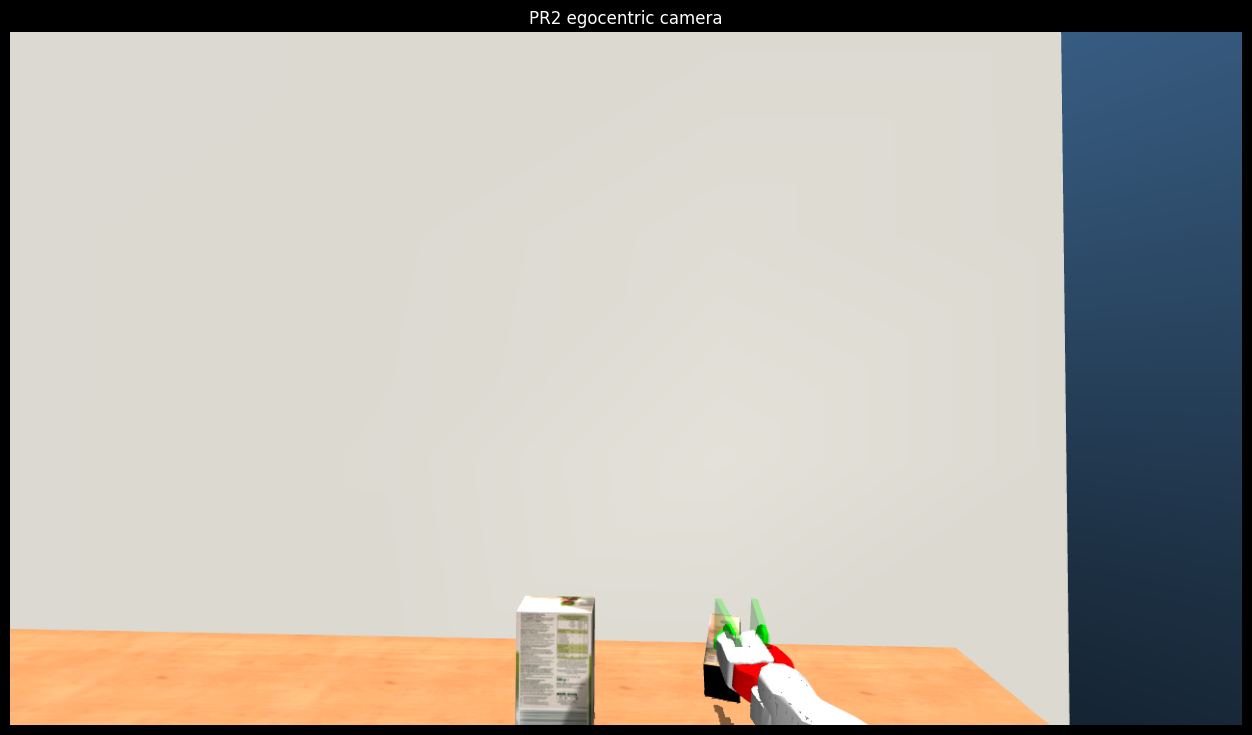

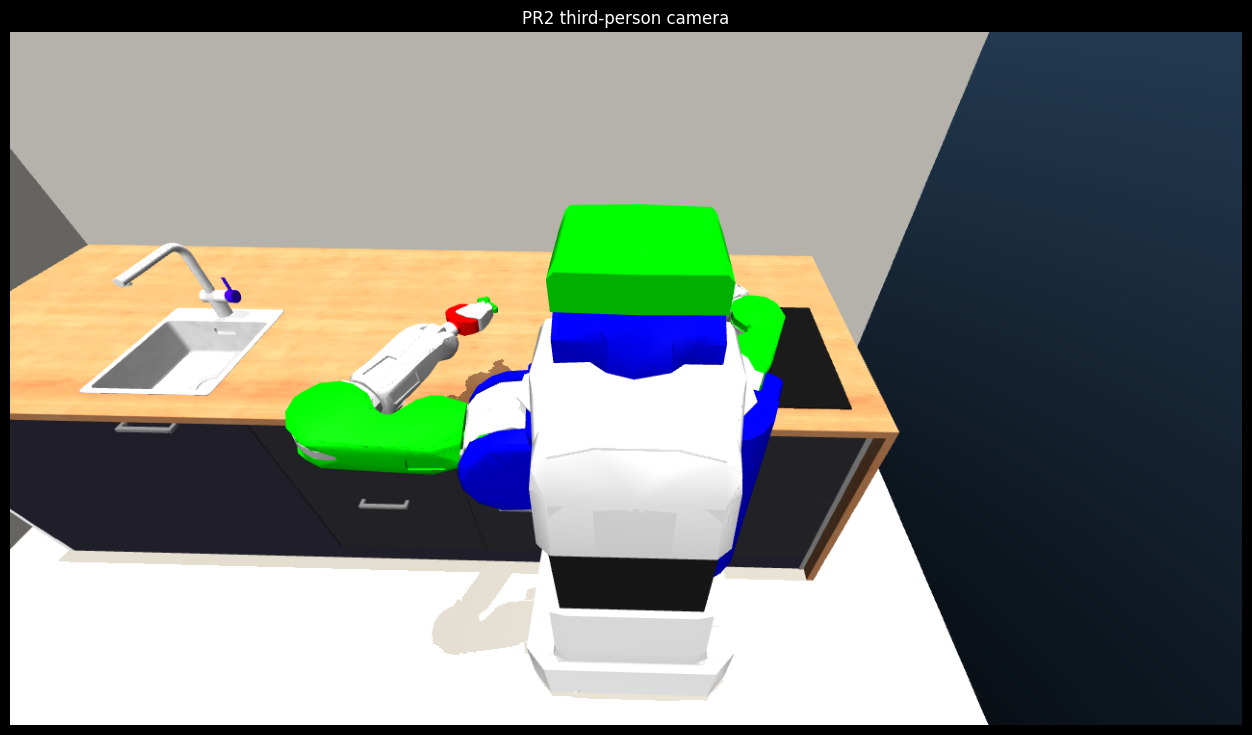

In [10]:
egocentric_rgb = capture_pr2_egocentric(show=not HEADLESS)
third_person_rgb = capture_pr2_third_person_view(show=not HEADLESS)


## Stop before rerunning


In [ ]:
if 'mujoco_control_callback' in globals():
    mujoco_control_callback.stop()
if 'synchronizer' in globals():
    synchronizer.stop()
if 'simulator' in globals():
    simulator.stop()
if 'rviz_marker_publisher' in globals():
    if rviz_marker_publisher._tf_publisher is not None:
        rviz_marker_publisher._tf_publisher.stop()
    rviz_marker_publisher.stop()
if 'rviz_executor' in globals():
    rviz_executor.shutdown(timeout_sec=1.0)
if 'rviz_executor_thread' in globals() and rviz_executor_thread.is_alive():
    rviz_executor_thread.join(timeout=1.0)
if 'rviz_node' in globals():
    rviz_node.destroy_node()
if globals().get('rviz_owns_rclpy', False) and rclpy.ok():
    rclpy.shutdown()
print('Scene and RViz publishers stopped.')
